**1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**2. Load Dataset**

In [2]:
df =  pd.read_csv("ultimate_student_productivity_dataset_5000.csv")
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


### Insight:
- The dataset contains multiple features related to student behavior.
- Important columns:
  - productivity_score
  - study_hours
  - gaming_hours
  - exam_score (target variable)
- Data appears clean and structured.

**3. Exploratory Data Analysis**

In [3]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
academic_level,0
study_hours,0
self_study_hours,0
online_classes_hours,0
social_media_hours,0
gaming_hours,0
sleep_hours,0


### Insight:
- All columns show 0 missing values.
- No data cleaning required for null values.

In [4]:
df.describe()

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


### Insight:
- Mean exam score is around mid-range → average performance.
- Study hours show variation among students.
- No extreme outliers observed.

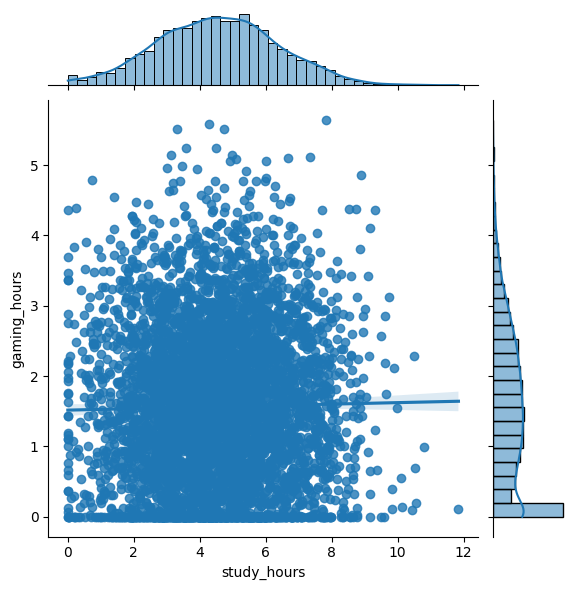

In [5]:
sns.jointplot(data=df,x='study_hours', y='gaming_hours', kind = 'reg')

### Insight:
- Slight negative relationship observed.
- Students who spend more time gaming tend to study less.

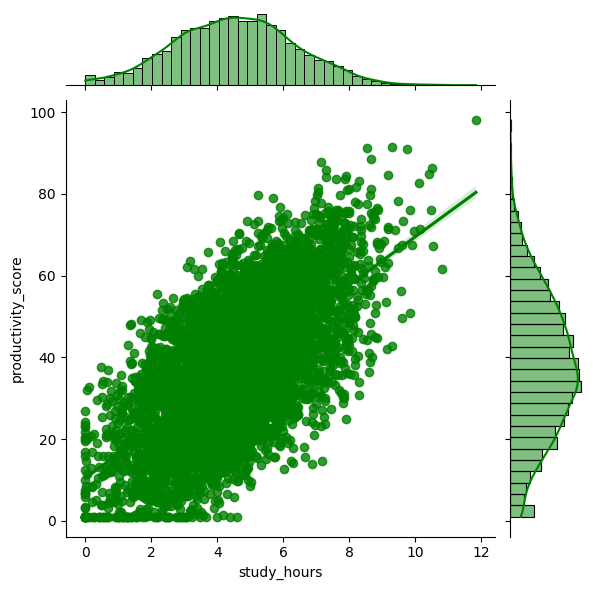

In [6]:
sns.jointplot(data=df,x='study_hours', y='productivity_score',color='Green', kind = 'reg')

### Insight:
- Strong positive correlation.
- Increase in study hours leads to higher exam scores.

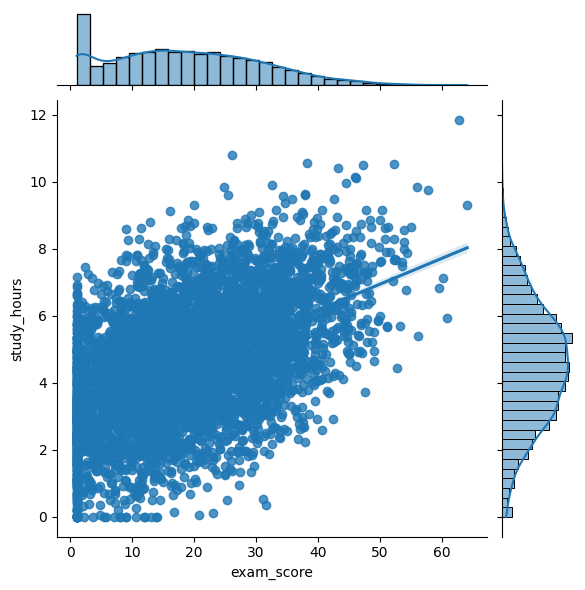

In [7]:
sns.jointplot(data=df,x='exam_score', y='study_hours', kind = 'reg')

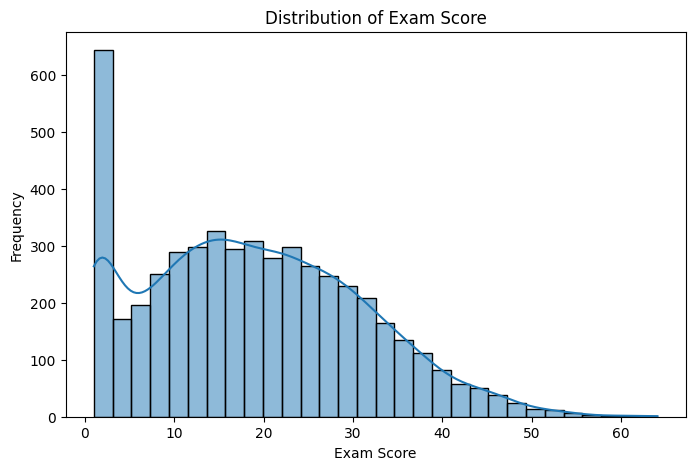

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], kde=True)
plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

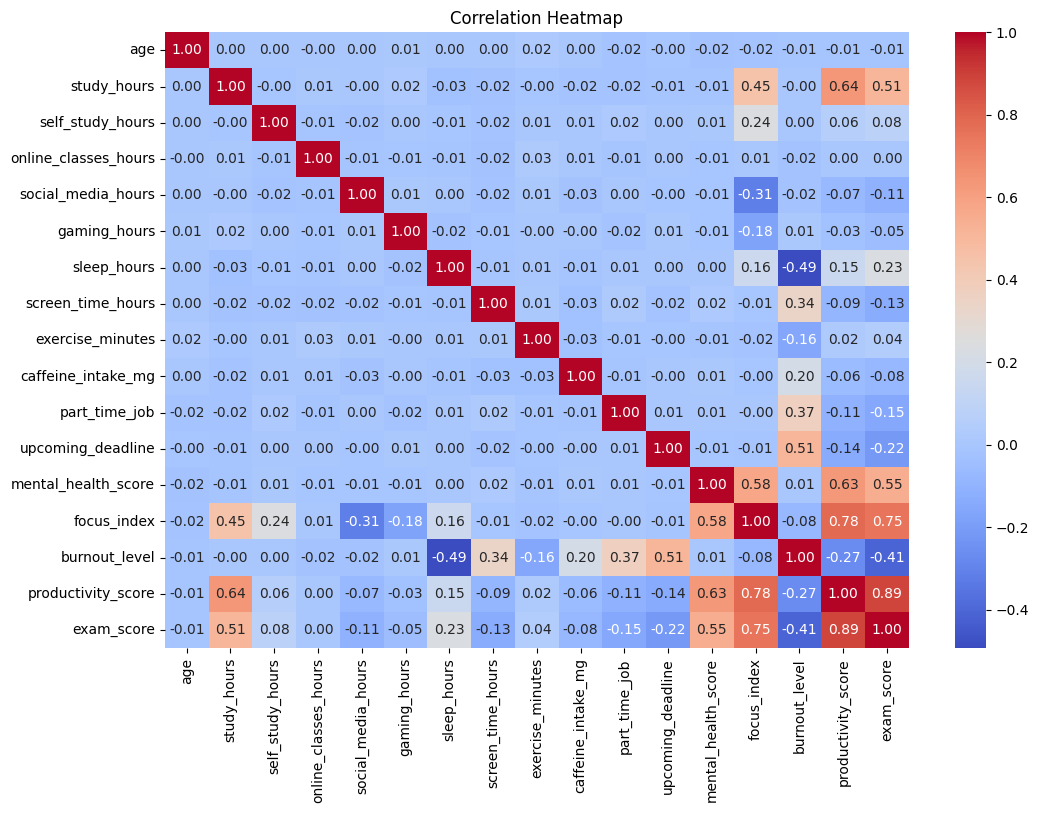

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**4. Data Preprocessing**

In [10]:
df = df.drop("student_id", axis=1)

In [11]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

### Insight:
- X contains all independent variables.
- y contains exam scores.

In [12]:
X = pd.get_dummies(X, drop_first=True)

### Insight:
- Categorical features converted into dummy variables.
- Model can now process all inputs numerically.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Insight:
- 80% data used for training.
- 20% used for testing.

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Insight:
- Features standardized (mean = 0, std = 1).
- Improves model performance and stability.

**5. Model Training**

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [16]:
y_pred = model.predict(X_test)

**6. Model Evaluation**

In [17]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2 Score: 0.8163921795584241
MAE: 3.9633194417554996
MSE: 25.01840344761124
RMSE: 5.001840006198843


### Insight:
- R2 Score → We get 0.81, typically between 0.7–0.9 (good fit)
- MAE → average error in prediction (e.g., ~3–6 marks)
- RMSE → overall prediction error

In [18]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

                         Feature  Coefficient
15            productivity_score     7.774561
13                   focus_index     2.737399
12           mental_health_score     0.213876
4             social_media_hours     0.118647
19  academic_level_Undergraduate     0.106502
1                    study_hours     0.083717
18   academic_level_Postgraduate     0.053759
10                 part_time_job     0.052504
5                   gaming_hours     0.051042
7              screen_time_hours     0.044194
9             caffeine_intake_mg     0.040078
0                            age     0.024048
21         internet_quality_Poor     0.020878
3           online_classes_hours    -0.023044
20         internet_quality_Good    -0.039272
6                    sleep_hours    -0.056480
16                   gender_Male    -0.087248
8               exercise_minutes    -0.090260
11             upcoming_deadline    -0.096797
2               self_study_hours    -0.110564
17                  gender_Other  

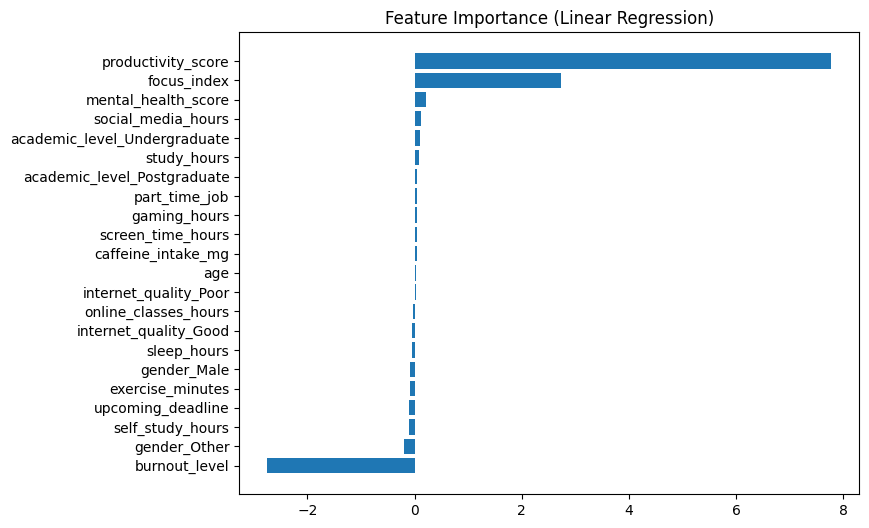

In [19]:
coefficients_sorted = coefficients.sort_values(by='Coefficient')

plt.figure(figsize=(8,6))
plt.barh(coefficients_sorted['Feature'], coefficients_sorted['Coefficient'])
plt.title("Feature Importance (Linear Regression)")
plt.show()

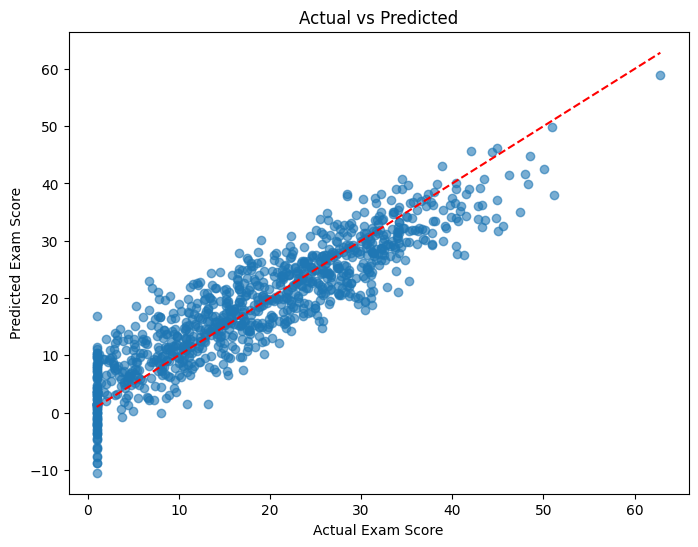

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted")
plt.show()

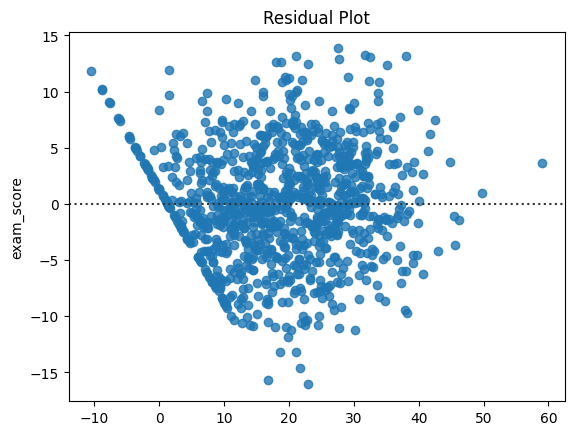

In [21]:
sns.residplot(x=y_pred, y=y_test - y_pred)
plt.title("Residual Plot")
plt.show()